**README**

* Upload the train.csv
* Upload all test files inidividually from the test folder

In [59]:
import os
import nltk
import string
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import hstack
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
from xgboost import XGBClassifier
from scipy.sparse import csr_matrix
from sklearn.feature_selection import f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.feature_extraction.text import TfidfVectorizer

In [21]:
trainDf = pd.read_csv('/content/train.csv')
trainDf.head()

,id,discourse_id,discourse_start,discourse_end,discourse_text,discourse_type,discourse_type_num,predictionstring
0,423A1CA112E2,1.622628e+12,8.0,229.0,Modern humans today are always on their phone....,Lead,Lead 1,1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 1...
1,423A1CA112E2,1.622628e+12,230.0,312.0,They are some really bad consequences when stu...,Position,Position 1,45 46 47 48 49 50 51 52 53 54 55 56 57 58 59
2,423A1CA112E2,1.622628e+12,313.0,401.0,Some certain areas in the United States ban ph...,Evidence,Evidence 1,60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75
3,423A1CA112E2,1.622628e+12,402.0,758.0,"When people have phones, they know about certa...",Evidence,Evidence 2,76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 9...
4,423A1CA112E2,1.622628e+12,759.0,886.0,Driving is one of the way how to get around. P...,Claim,Claim 1,139 140 141 142 143 144 145 146 147 148 149 15...


In [22]:
trainDf.info()

print("\n=== Missing Values per Column ===")
print(trainDf.isnull().sum())

print("\nTarget Variable:", "discourse_type")
print("Number of classes:", trainDf['discourse_type'].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144293 entries, 0 to 144292
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  144293 non-null  object 
 1   discourse_id        144293 non-null  float64
 2   discourse_start     144293 non-null  float64
 3   discourse_end       144293 non-null  float64
 4   discourse_text      144293 non-null  object 
 5   discourse_type      144293 non-null  object 
 6   discourse_type_num  144293 non-null  object 
 7   predictionstring    144293 non-null  object 
dtypes: float64(3), object(5)
memory usage: 8.8+ MB

=== Missing Values per Column ===
id                    0
discourse_id          0
discourse_start       0
discourse_end         0
discourse_text        0
discourse_type        0
discourse_type_num    0
predictionstring      0
dtype: int64

Target Variable: discourse_type
Number of classes: 7


**Pre-Processing**

Convert lables from categorical to numerical

In [23]:
discourse_type_mapping = {'Lead': 0, 'Position': 1, 'Claim': 2, 'Counterclaim' : 3,
                    'Rebuttal' : 4, 'Evidence' : 5, 'Concluding Statement' : 6}

trainDf['discourse_type_Encoded'] = trainDf['discourse_type'].map(discourse_type_mapping)
display(trainDf.head())

,id,discourse_id,discourse_start,discourse_end,discourse_text,discourse_type,discourse_type_num,predictionstring,discourse_type_Encoded
0,423A1CA112E2,1.622628e+12,8.0,229.0,Modern humans today are always on their phone....,Lead,Lead 1,1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 1...,0
1,423A1CA112E2,1.622628e+12,230.0,312.0,They are some really bad consequences when stu...,Position,Position 1,45 46 47 48 49 50 51 52 53 54 55 56 57 58 59,1
2,423A1CA112E2,1.622628e+12,313.0,401.0,Some certain areas in the United States ban ph...,Evidence,Evidence 1,60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75,5
3,423A1CA112E2,1.622628e+12,402.0,758.0,"When people have phones, they know about certa...",Evidence,Evidence 2,76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 9...,5
4,423A1CA112E2,1.622628e+12,759.0,886.0,Driving is one of the way how to get around. P...,Claim,Claim 1,139 140 141 142 143 144 145 146 147 148 149 15...,2


Convert entire text to lower case

In [24]:
trainDf['discourse_text'] = trainDf['discourse_text'].str.lower()
trainDf.head()

,id,discourse_id,discourse_start,discourse_end,discourse_text,discourse_type,discourse_type_num,predictionstring,discourse_type_Encoded
0,423A1CA112E2,1.622628e+12,8.0,229.0,modern humans today are always on their phone....,Lead,Lead 1,1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 1...,0
1,423A1CA112E2,1.622628e+12,230.0,312.0,they are some really bad consequences when stu...,Position,Position 1,45 46 47 48 49 50 51 52 53 54 55 56 57 58 59,1
2,423A1CA112E2,1.622628e+12,313.0,401.0,some certain areas in the united states ban ph...,Evidence,Evidence 1,60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75,5
3,423A1CA112E2,1.622628e+12,402.0,758.0,"when people have phones, they know about certa...",Evidence,Evidence 2,76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 9...,5
4,423A1CA112E2,1.622628e+12,759.0,886.0,driving is one of the way how to get around. p...,Claim,Claim 1,139 140 141 142 143 144 145 146 147 148 149 15...,2


Remove Stopwords

In [25]:
nltk.download('stopwords')
print("NLTK 'stopwords' corpus downloaded.")

# Define the set of stopwords
stop_words = set(stopwords.words('english'))

# Define a function to remove stopwords
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

# Apply the function to the 'discourse_text' column
trainDf['discourse_text'] = trainDf['discourse_text'].apply(remove_stopwords)

print("Stopwords removed from 'discourse_text' column.")
display(trainDf.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


NLTK 'stopwords' corpus downloaded.
Stopwords removed from 'discourse_text' column.


,id,discourse_id,discourse_start,discourse_end,discourse_text,discourse_type,discourse_type_num,predictionstring,discourse_type_Encoded
0,423A1CA112E2,1.622628e+12,8.0,229.0,modern humans today always phone. always phone...,Lead,Lead 1,1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 1...,0
1,423A1CA112E2,1.622628e+12,230.0,312.0,really bad consequences stuff happens comes ph...,Position,Position 1,45 46 47 48 49 50 51 52 53 54 55 56 57 58 59,1
2,423A1CA112E2,1.622628e+12,313.0,401.0,certain areas united states ban phones class r...,Evidence,Evidence 1,60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75,5
3,423A1CA112E2,1.622628e+12,402.0,758.0,"people phones, know certain apps .apps like fa...",Evidence,Evidence 2,76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 9...,5
4,423A1CA112E2,1.622628e+12,759.0,886.0,driving one way get around. people always phon...,Claim,Claim 1,139 140 141 142 143 144 145 146 147 148 149 15...,2


Remove Punctuations

In [26]:
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

trainDf['discourse_text'] = trainDf['discourse_text'].apply(remove_punctuation)
display(trainDf.head())

,id,discourse_id,discourse_start,discourse_end,discourse_text,discourse_type,discourse_type_num,predictionstring,discourse_type_Encoded
0,423A1CA112E2,1.622628e+12,8.0,229.0,modern humans today always phone always phone ...,Lead,Lead 1,1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 1...,0
1,423A1CA112E2,1.622628e+12,230.0,312.0,really bad consequences stuff happens comes phone,Position,Position 1,45 46 47 48 49 50 51 52 53 54 55 56 57 58 59,1
2,423A1CA112E2,1.622628e+12,313.0,401.0,certain areas united states ban phones class r...,Evidence,Evidence 1,60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75,5
3,423A1CA112E2,1.622628e+12,402.0,758.0,people phones know certain apps apps like face...,Evidence,Evidence 2,76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 9...,5
4,423A1CA112E2,1.622628e+12,759.0,886.0,driving one way get around people always phone...,Claim,Claim 1,139 140 141 142 143 144 145 146 147 148 149 15...,2


**EDA**

Discourse type Distribution

/tmp/ipython-input-279/3409986917.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=trainDf, x='discourse_type', palette='viridis')


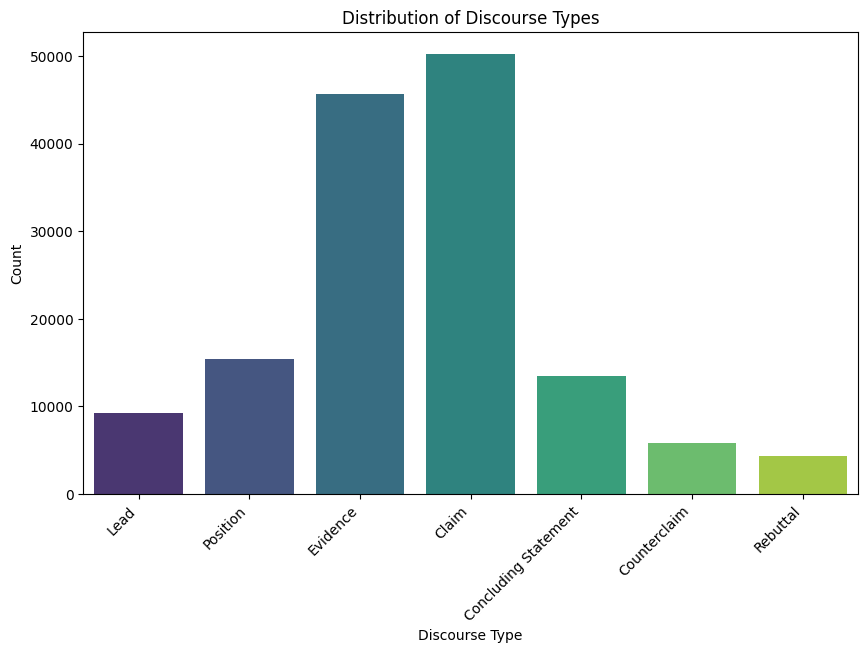

In [27]:
# Create a bar plot using seaborn.countplot()
plt.figure(figsize=(10, 6))
sns.countplot(data=trainDf, x='discourse_type', palette='viridis')

# Add title and labels
plt.title('Distribution of Discourse Types')
plt.xlabel('Discourse Type')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')

# Display the plot
plt.show()

Word clouds in each Discourse type

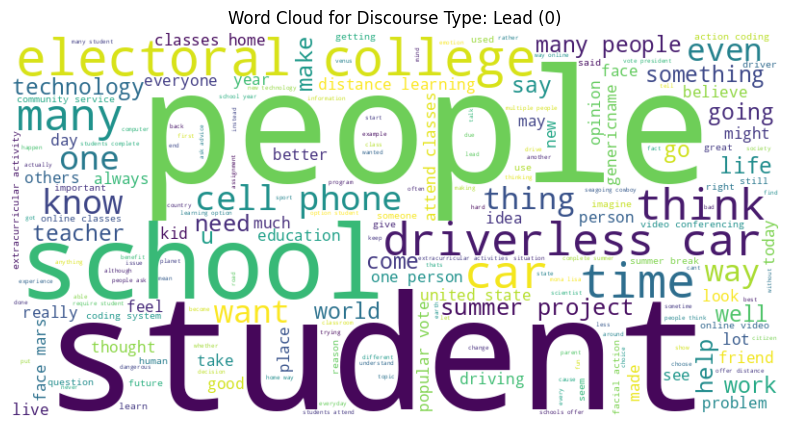

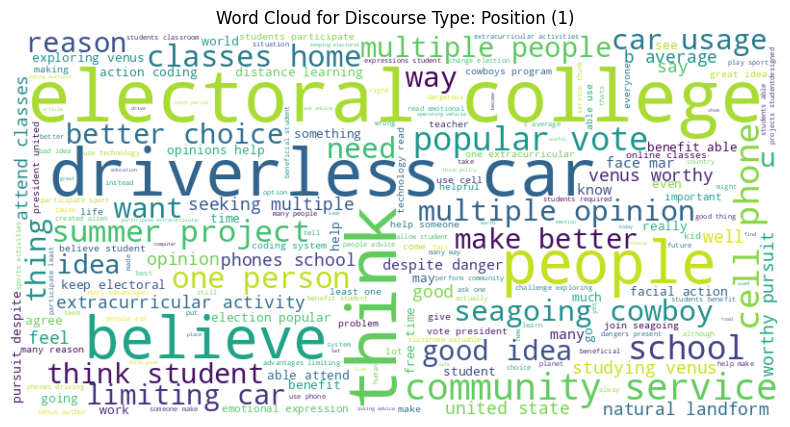

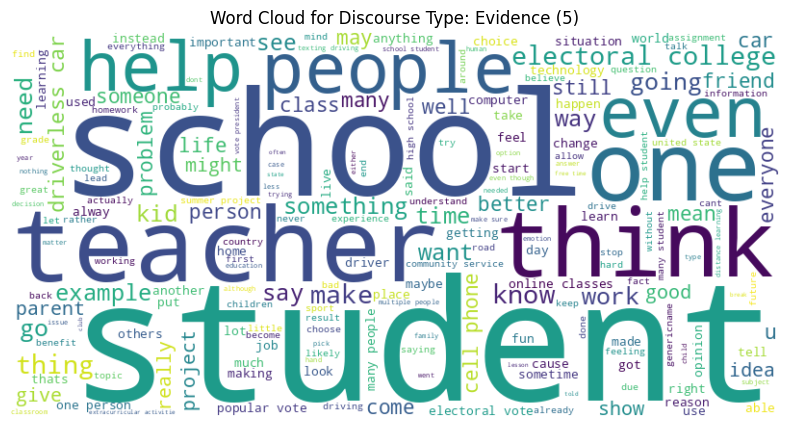

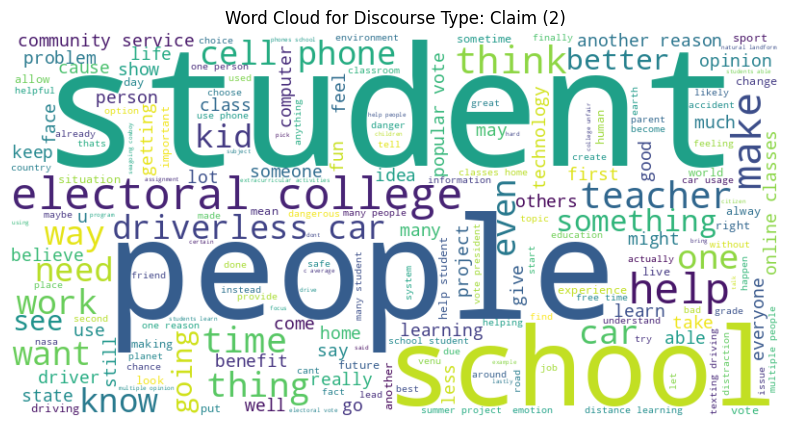

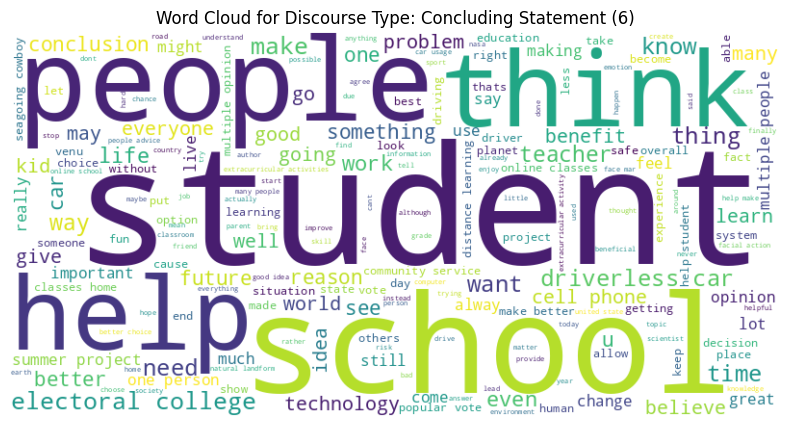

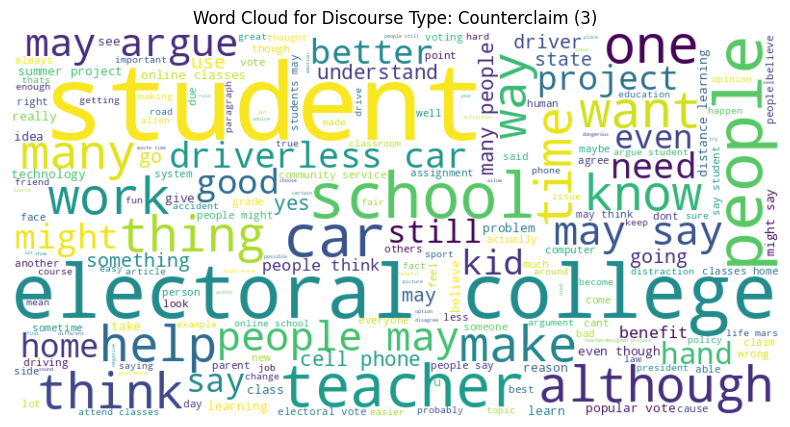

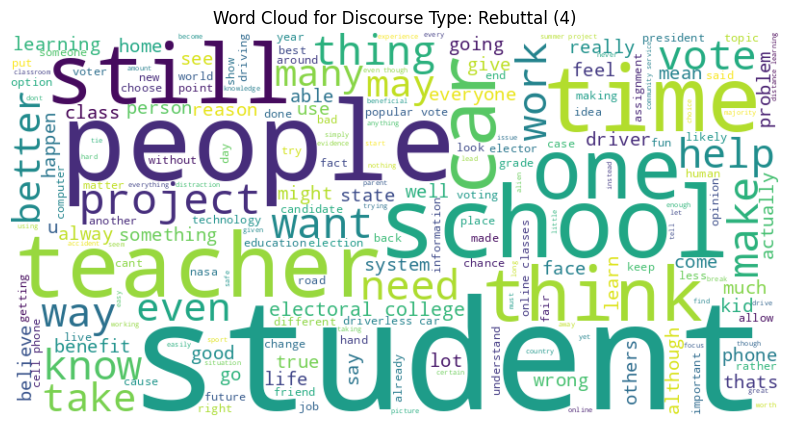

In [28]:
# Get unique discourse types
unique_discourse_types = trainDf['discourse_type_Encoded'].unique()

# Iterate through each discourse type and generate a word cloud
for discourse_type_code in unique_discourse_types:
    # Filter data for the current discourse type
    subset_df = trainDf[trainDf['discourse_type_Encoded'] == discourse_type_code]

    # Combine all discourse texts for this type into a single string
    text_combined = " ".join(subset_df['discourse_text'])

    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_combined)

    # Get the original discourse type name for the title
    discourse_type_name = [name for name, code in discourse_type_mapping.items() if code == discourse_type_code][0]

    # Display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for Discourse Type: {discourse_type_name} ({discourse_type_code})')
    plt.show()

Word count in each Discourse type

/tmp/ipython-input-279/3060722918.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=trainDf, x='discourse_type', y='word_count', palette='viridis')


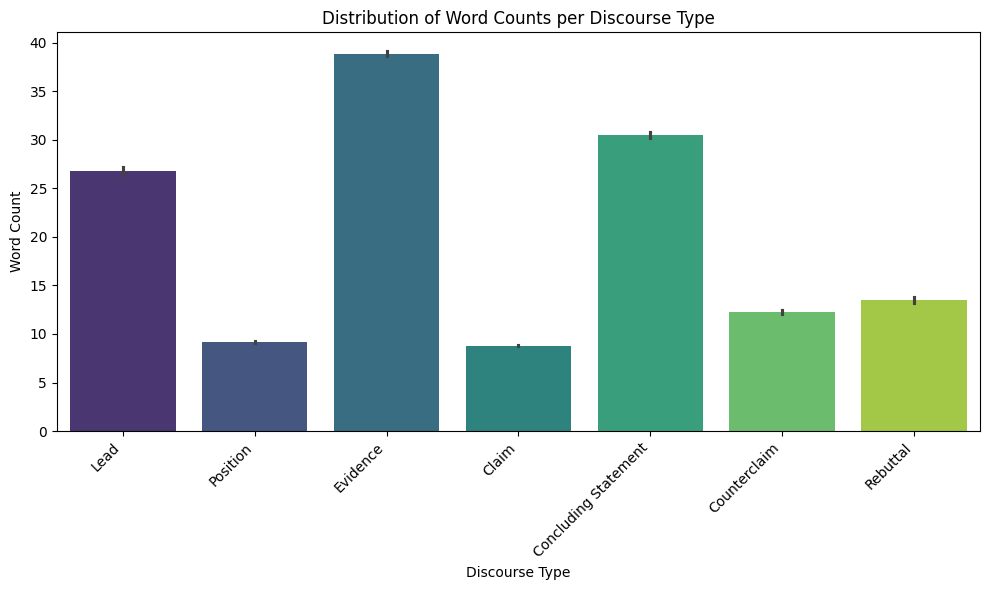

In [29]:
# Calculate the number of words for each discourse text
trainDf['word_count'] = trainDf['discourse_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 6))
sns.barplot(data=trainDf, x='discourse_type', y='word_count', palette='viridis')
plt.title('Distribution of Word Counts per Discourse Type')
plt.xlabel('Discourse Type')
plt.ylabel('Word Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Feature Engineering

In [30]:
numerical_features = ['id','discourse_start', 'discourse_end', 'word_count', 'text_length']
print(f"Identified numerical features: {numerical_features}")

Identified numerical features: ['id', 'discourse_start', 'discourse_end', 'word_count', 'text_length']


Check how much these numerical features contribute towards the target variable

### Quantify Feature Contribution (F-values) and Normalize

We'll re-calculate the ANOVA F-values for all selected numerical features (`id`, `discourse_start`, `discourse_end`, `word_count`) against the `discourse_type_Encoded` target. These F-values measure the statistical significance of the relationship between each numerical feature and the categorical target. Then, we'll normalize these F-values to a 0-1 scale to represent a 'probabilistic score' of contribution.

In [33]:
# Ensure 'text_length' is calculated for trainDf
trainDf['text_length'] = trainDf['discourse_text'].apply(len)

# Ensure X for f_classif includes the factorized 'id' and other numerical features
X_for_f_test = trainDf[numerical_features].copy()
X_for_f_test['id'] = pd.factorize(X_for_f_test['id'])[0] # Ensure 'id' is numerical

y = trainDf['discourse_type_Encoded']

f_values, p_values = f_classif(X_for_f_test, y)

# Normalize F-values to a 0-1 scale
# Avoid division by zero if all F-values are the same (unlikely but good practice)
max_f = np.max(f_values)
min_f = np.min(f_values)
if max_f == min_f:
    normalized_f_values = np.array([1.0] * len(f_values))
else:
    normalized_f_values = (f_values - min_f) / (max_f - min_f)

# Create a DataFrame for plotting
feature_contribution_df = pd.DataFrame({
    'Feature': numerical_features,
    'Contribution Score': normalized_f_values
}).sort_values(by='Contribution Score', ascending=False)

print("Normalized Feature Contributions (based on F-values):")
display(feature_contribution_df)

Normalized Feature Contributions (based on F-values):


,Feature,Contribution Score
3,word_count,1.000000
4,text_length,0.936952
2,discourse_end,0.833728
1,discourse_start,0.745253
0,id,0.000000


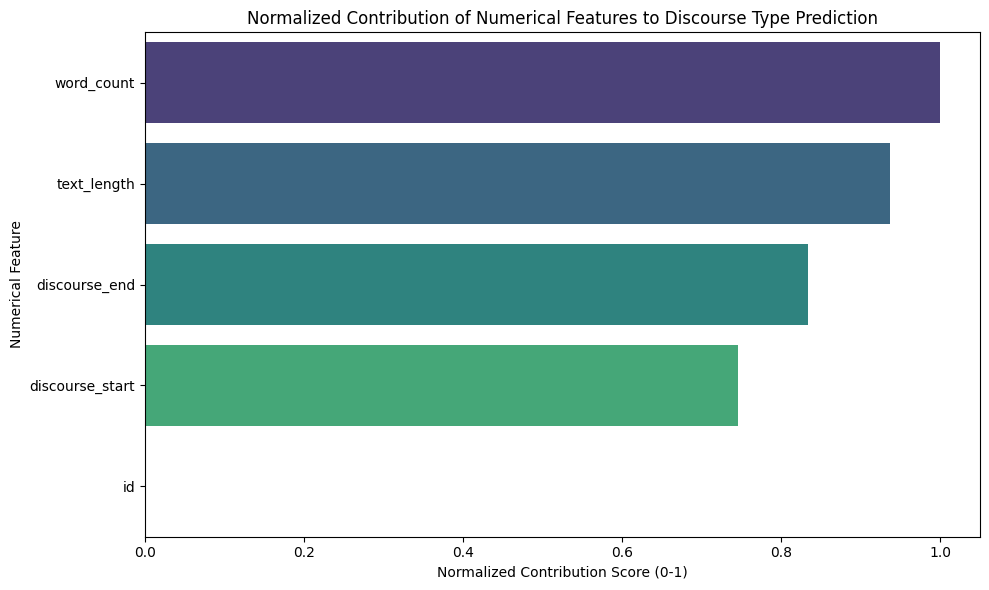

In [34]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Contribution Score', y='Feature', data=feature_contribution_df, palette='viridis', hue='Feature', legend=False)
plt.title('Normalized Contribution of Numerical Features to Discourse Type Prediction')
plt.xlabel('Normalized Contribution Score (0-1)')
plt.ylabel('Numerical Feature')
plt.tight_layout()
plt.show()

Re-Selecting numerical features

In [35]:
numerical_features = ['discourse_start', 'discourse_end', 'word_count', 'text_length']
print(f"Identified numerical features: {numerical_features}")

Identified numerical features: ['discourse_start', 'discourse_end', 'word_count', 'text_length']


**TF-IDF**

However, the key purpose and power of TF-IDF (Term Frequency-Inverse Document Frequency) goes beyond just numerical conversion. Its main goal is to reflect how important a word is to a document in a collection or corpus.

Here's a breakdown:

Term Frequency (TF): This part measures how frequently a term appears in a document. A higher TF means the word is more present in that specific document.
Inverse Document Frequency (IDF): This part measures how rare or common a term is across all documents in the corpus. A word that appears in many documents will have a low IDF, meaning it's less unique or distinguishing. A word that appears in only a few documents will have a high IDF, meaning it's more specific and potentially more informative.
By multiplying TF and IDF, the score emphasizes words that are:

Frequent within a specific document (high TF).
Rare across the entire corpus (high IDF).
So, while it converts words to numbers, its purpose is to assign weights to words that signify their contextual importance, helping models understand which words are most relevant for distinguishing between different documents or classes (like your discourse types). It helps filter out common, less informative words (like many stopwords, though you've already removed those) and highlight the more distinctive ones.

In [36]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(trainDf['discourse_text'])
print(f"Shape of TF-IDF feature matrix X: {X.shape}")

Shape of TF-IDF feature matrix X: (144293, 58528)


In [37]:
# Define the number of top features to select
k = 20000

# Instantiate SelectKBest with chi2 as the score function and k value
selector = SelectKBest(chi2, k=k)

# Fit and transform the TF-IDF matrix X and the target variable
X_selected = selector.fit_transform(X, trainDf['discourse_type_Encoded'])

print(f"Shape of X_selected after feature selection: {X_selected.shape}")

Shape of X_selected after feature selection: (144293, 20000)


In [38]:
X_numerical_features = trainDf[numerical_features].copy()
print(f"Shape of numerical features matrix: {X_numerical_features.shape}")
display(X_numerical_features.head())

Shape of numerical features matrix: (144293, 4)


,discourse_start,discourse_end,word_count,text_length
0,8.0,229.0,21,122
1,230.0,312.0,7,49
2,313.0,401.0,9,53
3,402.0,758.0,33,233
4,759.0,886.0,12,73


In [39]:
X_numerical_features_array = X_numerical_features.to_numpy()
print(f"Shape of numerical features NumPy array: {X_numerical_features_array.shape}")

Shape of numerical features NumPy array: (144293, 4)


In [40]:
# Combine the sparse TF-IDF features (X_selected) with the dense numerical features (X_numerical_features_array)
X_final = hstack([X_selected, X_numerical_features_array])

print(f"Shape of final combined feature matrix X_final: {X_final.shape}")

Shape of final combined feature matrix X_final: (144293, 20004)


Why should we use Group Shuffle -

Nature of Your Data: Your dataset contains multiple discourse_text entries (rows) that belong to the same essay, identified by the id column. These entries from a single essay are inherently related and share contextual information.

What happens with standard train_test_split: A standard train_test_split shuffles all individual rows randomly and then splits them. This means that segments from the same essay (id) could end up in both your training set and your test set.

The Problem - Data Leakage: If parts of the same essay are in both training and test sets, your model will effectively have 'seen' information related to the test essays during training. When you evaluate your model on the test set, it will appear to perform much better than it actually would on completely unseen, new essays. This leads to an overly optimistic and misleading evaluation of your model's real-world performance.

Why GroupShuffleSplit helps: GroupShuffleSplit (and other group-aware splitters like GroupKFold) ensures that all entries belonging to the same group (in your case, the id of an essay) are kept together. This means an entire essay will either be in the training set or in the test set, but never split across both. This setup correctly simulates a real-world scenario where your model would encounter entirely new essays it has never seen before.

In [41]:
y_final = trainDf['discourse_type_Encoded']

# Convert X_final to CSR format for efficient row slicing
X_final_csr = csr_matrix(X_final)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in gss.split(X_final_csr, y_final, groups=trainDf['id']):
    X_train, X_test = X_final_csr[train_idx], X_final_csr[test_idx]
    y_train, y_test = y_final.iloc[train_idx], y_final.iloc[test_idx]

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (115436, 20004)
Shape of X_test: (28857, 20004)
Shape of y_train: (115436,)
Shape of y_test: (28857,)


In [43]:
# Initialize Logistic Regression model
# Set solver='saga' and max_iter to a sufficiently large number (e.g., 5000) to ensure convergence.
# multi_class='multinomial' is the default for 'saga' solver and will be removed in future versions.
log_reg_model = LogisticRegression(solver='saga', max_iter=5000, random_state=42, n_jobs=-1)

# Train the model
print("Training Logistic Regression model...")
log_reg_model.fit(X_train, y_train)
print("Logistic Regression model trained.")

# Make predictions on the test set
print("Making predictions...")
y_pred_log_reg = log_reg_model.predict(X_test)
print("Predictions made.")

# Calculate accuracy and F1-score
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg, average='macro')

# Print the results
print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")
print(f"Logistic Regression F1-score (macro): {f1_log_reg:.4f}")

Training Logistic Regression model...
Logistic Regression model trained.
Making predictions...
Predictions made.
Logistic Regression Accuracy: 0.5236
Logistic Regression F1-score (macro): 0.2918


In [44]:
# Initialize XGBoost classifier
# objective='multi:softmax' for multi-class classification
# num_class=7 as there are 7 unique discourse types (0-6)
# n_jobs=-1 to use all available processors for parallel processing
xgb_model = XGBClassifier(objective='multi:softmax', num_class=7, random_state=42, n_jobs=-1, eval_metric='mlogloss')

# Train the model
print("Training XGBoost model...")
xgb_model.fit(X_train, y_train)
print("XGBoost model trained.")

# Make predictions on the test set
print("Making predictions...")
y_pred_xgb = xgb_model.predict(X_test)
print("Predictions made.")

# Calculate accuracy and F1-score
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb, average='macro')

# Print the results
print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")
print(f"XGBoost F1-score (macro): {f1_xgb:.4f}")

Training XGBoost model...
XGBoost model trained.
Making predictions...
Predictions made.
XGBoost Accuracy: 0.7566
XGBoost F1-score (macro): 0.6348


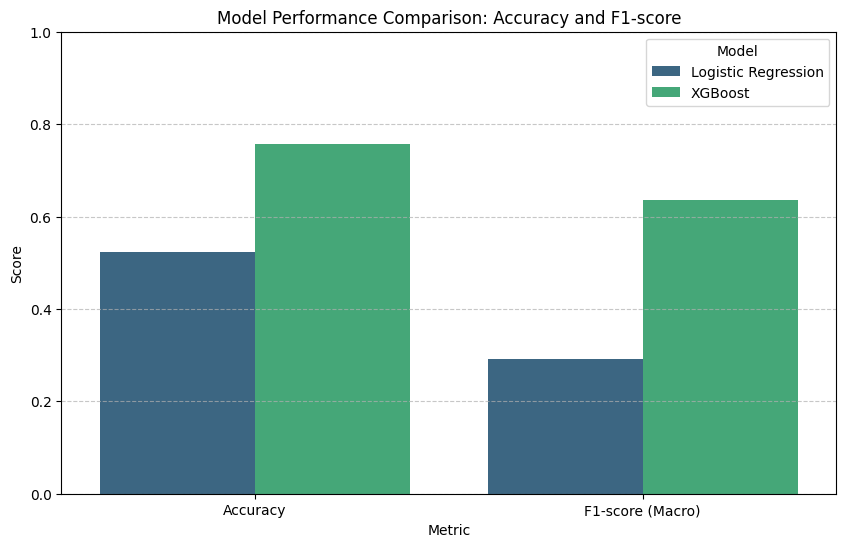

In [58]:
# Model performance metrics (assuming these variables are available in the notebook state)
# accuracy_log_reg, f1_log_reg, accuracy_xgb, f1_xgb

performance_data = {
    'Model': ['Logistic Regression', 'XGBoost', 'Logistic Regression', 'XGBoost'],
    'Metric': ['Accuracy', 'Accuracy', 'F1-score (Macro)', 'F1-score (Macro)'],
    'Score': [accuracy_log_reg, accuracy_xgb, f1_log_reg, f1_xgb]
}

performance_df = pd.DataFrame(performance_data)

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=performance_df, palette='viridis')
plt.title('Model Performance Comparison: Accuracy and F1-score')
plt.ylabel('Score')
plt.ylim(0, 1) # Scores are between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Testing**

Upload test data - .txt files and create a folder -> test_files

In [45]:
import nltk
nltk.download('punkt')
print("NLTK 'punkt' tokenizer downloaded.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


NLTK 'punkt' tokenizer downloaded.


In [47]:
import nltk
import os
import shutil # Import shutil for moving files
nltk.download('punkt_tab')

TEST_PATH = "/content/test_files"

# Create the directory if it does not exist
if not os.path.exists(TEST_PATH):
    os.makedirs(TEST_PATH)
    print(f"Created directory: {TEST_PATH}")

# Move existing test .txt files from /content/ to /content/test_files
# Identify relevant test files from the kernel's file list
test_file_names = ['0FB0700DAF44.txt', 'DF920E0A7337.txt', 'D72CB1C11673.txt', 'D46BCB48440A.txt', '18409261F5C2.txt']

for fname in test_file_names:
    source_path = os.path.join('/content/', fname)
    destination_path = os.path.join(TEST_PATH, fname)
    if os.path.exists(source_path) and not os.path.exists(destination_path):
        shutil.move(source_path, destination_path)
        print(f"Moved {fname} to {TEST_PATH}")
    elif not os.path.exists(source_path):
        print(f"Warning: {fname} not found in /content/")

def get_test_text(a_id):
    a_file = f"{TEST_PATH}/{a_id}.txt"
    with open(a_file, "r") as fp:
        txt = fp.read()
    return txt

def create_df_test():
    test_ids = [f[:-4] for f in os.listdir(TEST_PATH)] #Remove the last 4 characters ('.txt') in the filenames such as '0FB0700DAF44.txt'.
    test_data = []
    for test_id in test_ids:
        text = get_test_text(test_id)
        sentences = nltk.sent_tokenize(text)
        id_sentences = []
        idx = 0
        for sentence in sentences:
            id_sentence = []
            words = sentence.split()
            # I created this heuristic for mapping words in sentences to "word indices"
            # This is not definitive and might have strong drawbacks and problems
            for w in words:
              id_sentence.append(idx)
              idx+=1
            id_sentences.append(id_sentence)
        test_data += list(zip([test_id] * len(sentences), sentences, id_sentences))
    df_test = pd.DataFrame(test_data, columns=['id', 'discourse_text', 'ids'])
    return df_test

df_test = create_df_test()
df_test.head()

Created directory: /content/test_files
Moved 0FB0700DAF44.txt to /content/test_files
Moved DF920E0A7337.txt to /content/test_files
Moved D72CB1C11673.txt to /content/test_files
Moved D46BCB48440A.txt to /content/test_files
Moved 18409261F5C2.txt to /content/test_files


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,id,discourse_text,ids
0,D72CB1C11673,Making choices in life can be very difficult.,"[0, 1, 2, 3, 4, 5, 6, 7]"
1,D72CB1C11673,People often ask for advice when they can not ...,"[8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,..."
2,D72CB1C11673,It's always good to ask others for their advic...,"[21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 3..."
3,D72CB1C11673,When you have multiple opinions you have the a...,"[34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 4..."
4,D72CB1C11673,Seeking multiple opinions can help a person ma...,"[50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 6..."


Create TF-IDF of the text column

In [48]:
X_test_tfidf = vectorizer.transform(df_test['discourse_text'])
X_test_selected = selector.transform(X_test_tfidf)

print(f"Shape of X_test_tfidf after vectorization: {X_test_tfidf.shape}")
print(f"Shape of X_test_selected after feature selection: {X_test_selected.shape}")

Shape of X_test_tfidf after vectorization: (187, 58528)
Shape of X_test_selected after feature selection: (187, 20000)


Add discourse_start and end to the testDf

In [49]:
import nltk
nltk.download('punkt_tab')

TEST_PATH = "/content/test_files"

def get_test_text(a_id):
    a_file = f"{TEST_PATH}/{a_id}.txt"
    with open(a_file, "r") as fp:
        txt = fp.read()
    return txt

def create_df_test():
    test_ids = [f[:-4] for f in os.listdir(TEST_PATH)]
    test_data = []
    for test_id in test_ids:
        full_essay_text = get_test_text(test_id)

        # Use NLTK's Punkt Sentence Tokenizer to get spans (start, end character offsets)
        tokenizer = nltk.data.load('tokenizers/punkt/english.pickle')
        spans = list(tokenizer.span_tokenize(full_essay_text))

        current_word_idx = 0 # Tracks word index across the entire essay for 'ids' column
        for start_char, end_char in spans:
            sentence_text = full_essay_text[start_char:end_char]

            sentence_word_ids = []
            words_in_sentence = sentence_text.split() # Simple split to get words

            for _ in words_in_sentence:
                sentence_word_ids.append(current_word_idx)
                current_word_idx += 1

            test_data.append({
                'id': test_id,
                'discourse_text': sentence_text,
                'discourse_start': float(start_char), # Add discourse_start as a float
                'discourse_end': float(end_char),     # Add discourse_end as a float
                'ids': sentence_word_ids
            })

    df_test = pd.DataFrame(test_data)
    return df_test

df_test = create_df_test()
df_test.head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,id,discourse_text,discourse_start,discourse_end,ids
0,D72CB1C11673,Making choices in life can be very difficult.,0.0,45.0,"[0, 1, 2, 3, 4, 5, 6, 7]"
1,D72CB1C11673,People often ask for advice when they can not ...,46.0,112.0,"[8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,..."
2,D72CB1C11673,It's always good to ask others for their advic...,113.0,182.0,"[21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 3..."
3,D72CB1C11673,When you have multiple opinions you have the a...,183.0,273.0,"[34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 4..."
4,D72CB1C11673,Seeking multiple opinions can help a person ma...,274.0,452.0,"[50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 6..."


Perform text preprocessing and compute text length and word count

In [50]:
df_test['discourse_text'] = df_test['discourse_text'].str.lower()
df_test['discourse_text'] = df_test['discourse_text'].apply(remove_stopwords)
df_test['discourse_text'] = df_test['discourse_text'].apply(remove_punctuation)
df_test['word_count'] = df_test['discourse_text'].apply(lambda x: len(x.split()))
df_test['text_length'] = df_test['discourse_text'].apply(len)

print("Pre-processing, word_count, and text_length calculated for df_test.")
display(df_test.head())

Pre-processing, word_count, and text_length calculated for df_test.


,id,discourse_text,discourse_start,discourse_end,ids,word_count,text_length
0,D72CB1C11673,making choices life difficult,0.0,45.0,"[0, 1, 2, 3, 4, 5, 6, 7]",4,29
1,D72CB1C11673,people often ask advice decide one thing,46.0,112.0,"[8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,...",7,40
2,D72CB1C11673,always good ask others advice making choice,113.0,182.0,"[21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 3...",7,43
3,D72CB1C11673,multiple opinions ability make best choice you...,183.0,273.0,"[34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 4...",7,51
4,D72CB1C11673,seeking multiple opinions help person make bet...,274.0,452.0,"[50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 6...",18,131


Combine numerical features and TF-IDF to create test data

In [51]:
X_test_numerical_features = df_test[numerical_features].copy()
X_test_numerical_features_array = X_test_numerical_features.to_numpy()

# Combine the sparse TF-IDF features with the dense numerical features for the test set
X_test_final = hstack([X_test_selected, X_test_numerical_features_array])

print(f"Shape of final combined test feature matrix X_test_final: {X_test_final.shape}")

Shape of final combined test feature matrix X_test_final: (187, 20004)


Make Predictions

In [52]:
print("Making predictions on test data using XGBoost model...")
test_predictions = xgb_model.predict(X_test_final)
print("Predictions made.")

Making predictions on test data using XGBoost model...
Predictions made.


First 5

In [53]:
reverse_discourse_type_mapping = {v: k for k, v in discourse_type_mapping.items()}
predicted_discourse_types = [reverse_discourse_type_mapping[pred] for pred in test_predictions]

print(f"First 5 predicted discourse types: {predicted_discourse_types[:5]}")

First 5 predicted discourse types: ['Lead', 'Claim', 'Claim', 'Claim', 'Claim']


In [54]:
submission_df = pd.DataFrame({'id': df_test['id'], 'discourse_type': predicted_discourse_types})

print("Submission DataFrame created.")
display(submission_df.head())

Submission DataFrame created.


,id,discourse_type
0,D72CB1C11673,Lead
1,D72CB1C11673,Claim
2,D72CB1C11673,Claim
3,D72CB1C11673,Claim
4,D72CB1C11673,Claim


All Predictions

In [55]:
reverse_discourse_type_mapping = {v: k for k, v in discourse_type_mapping.items()}
predicted_discourse_types = [reverse_discourse_type_mapping[pred] for pred in test_predictions]

print(f"All predicted discourse types: {predicted_discourse_types}")

All predicted discourse types: ['Lead', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Evidence', 'Claim', 'Claim', 'Concluding Statement', 'Claim', 'Claim', 'Claim', 'Claim', 'Lead', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Rebuttal', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Rebuttal', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Rebuttal', 'Claim', 'Rebuttal', 'Claim', 'Claim', 'Lead', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Evidence', 'Claim', 'Evidence', 'Evidence', 'Claim', 'Rebuttal', 'Claim', 'Claim', 'Claim', 'Evidence', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Lead', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 'Claim', 

In [56]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

submission_df = pd.DataFrame({'id': df_test['id'], 'discourse_type': predicted_discourse_types})

print("Submission DataFrame created and displayed in full.")
display(submission_df)

Submission DataFrame created and displayed in full.


,id,discourse_type
0,D72CB1C11673,Lead
1,D72CB1C11673,Claim
2,D72CB1C11673,Claim
3,D72CB1C11673,Claim
4,D72CB1C11673,Claim
5,D72CB1C11673,Claim
6,D72CB1C11673,Claim
7,D72CB1C11673,Claim
8,D72CB1C11673,Claim
9,D72CB1C11673,Claim
